                                        ΕΡΓΑΣΙΑ ΑΡΙΘΜΗΤΙΚΗΣ ΑΝΑΛΥΣΗΣ 2023

ΣΥΝΑΡΤΗΣΗ ΕΚΤΥΠΩΣΗΣ:

Κάτι το οποίο σίγουρα θα χρειαστούμε, είναι μια απλή συνάρτηση για την εκτύπωση πινάκων, ώστε να μπορούμε να ελέγχουμε το πρόγραμμα. Η συνάρτηση δέχεται ως όρισμα έναν πίνακα, τον οποίο και διατρέχει σε όλο του το μέγεθος, εκτυπώνοντας τα στοιχεία του με formated τρόπο.Η εντολή print("{:30}".format(value),end='') δεσμεύει χώρο ακριβώς 30 ψηφίων για την εκτύπωση, ώστε να χωράνε τα πολλά δεκαδικά στοιχεία που μάλλον θα προκύπτουν και να είναι όλες ευθυγραμμισμένες. Η προσθήκη end='' αποτρέπει την αλλαγή γραμμής μετά την εκτύπωση κάθε τιμής. Η default συνάρτηση print() δύναται να τυπώσει πίνακες, χωρίς όμως επιλογές για μορφοποίηση.

In [1]:
import numpy as np


def PrintMatrix(matrix):
    for row in matrix:
        for value in row:
            print("{:30}".format(str(value)),end='')
        print()
    print("\n\n\n")    

ΤΡΟΠΟΠΟΙΗΜΕΝΗ ΣΥΝΑΡΤΗΣΗ LUmine:

Η συνάρτηση LUmine, όπως είναι δοσμένη, μας δημιούργησε ορισμένα προβλήματα. Συγκεκριμένα, δεν καταφέραμε να βρούμε τρόπο ώστε να αποφύγουμε τα compilation errors χωρίς αλλαγές στον κώδικα. Τα errors αυτά προέκυπταν λόγω της εντολής U=A, η οποία ταυτίζει τα δύο αντικείμενα στην μνήμη. Έτσι, όταν επεξεργαζόμαστε τον U, προκύπτουν αναπόφευκτα αλλαγές στον Α. Το πιο πιθανό είναι πως τα θέματα θα μπορούσαν να λυθούν με κάποια διαφορετική προσέγγιση. Κατόπιν έρευνας όμως, διαπιστώσαμε πως είναι πιο ασφαλές προγραμματιστικά να μην ταυτίζουμε δύο αντικείμενα. Ακολουθεί η τροποποιημένη συνάρτηση: Η συνάρτηση λαμβάνει τις διαστάσεις του Α και έπειτα αρχικοποιεί έναν identity μοναδιάιο πίνακα L ομοίων διαστάσεων. Ο U πλέον αρχικοποιείται ως αντίγραφο του Α. Τα loops που ακολουθούν εκτελούν την απαλοιφή Gauss στον πίνακα U. To j διατρέχει τον U από την πρώτη έως και την προ τελευταία στήλη, καθώς η τελευταία δεν χρειάζεται να πειραχτεί για την επίτευξη άνω τριγωνικής μορφής. To i έχει αρχική τιμή j+1 επειδή επιδιώκουμε απαλοιφή των στοιχείων μόνο κάτω της κύριας διαγωνίου. To mult πρόκειται για την αναλογία του του προς απαλοιφή στοιχείου με το pivot. Στην επόμενη ακριβώς γραμμή εκτελείται η διαδικασια της απαλοιφής. Η pivot row πολλαπλασιάζεται με mult (συγκεκριμένα τα στοιχεία δεξία του pivot, αφού γνωρίζουμε πως αυτά που βρίσκονται αριστερά θα μηδενιστούν σίγουρα αργότερα με την εντολή U[i, j] = 0) και αφαιρείται από την αντίστοιχη γραμμή. Στην συνέχεια, το mult αποθηκεύεται στο L[i,j]. Να σημειωθεί εδώ πως ο κώδικας μας δεν αποκλείει διαίρεση με το 0, όμως αυτό δεν φαίνεται να μας απασχολήσει βλέποντας τα επόμενα ερωτήματα.

In [3]:
def LUmine(A):
    A=A.astype(float) #Το typecasting χρειάστηκε λόγω του mult, το οποίο είναι float
    n=A.shape[0]
    L=np.identity(n)
    U=A.copy()
    for j in range(0,n-1):
        for i in range(j+1,n):
            mult=U[i, j] / U[j, j]
            U[i,j+1:n]=U[i,j+1:n]-mult*U[j,j+1:n]    #Απαλοι΄φη στοιχείου κάτω απο την κύρια διαγώνιο
            L[i,j]=mult
            U[i,j]=0
    return L,U

A=np.array([[1,2,3],[4,5,6],[7,8,6]])

PrintMatrix(A)

L,U=LUmine(A)

PrintMatrix(L)

PrintMatrix(U)

C=np.dot(L,U) #Ας επαληθεύσουμε

PrintMatrix(C)

1                             2                             3                             
4                             5                             6                             
7                             8                             6                             




1.0                           0.0                           0.0                           
4.0                           1.0                           0.0                           
7.0                           2.0                           1.0                           




1.0                           2.0                           3.0                           
0.0                           -3.0                          -6.0                          
0.0                           0.0                           -3.0                          




1.0                           2.0                           3.0                           
4.0                           5.0                           6.0               

ΣΥΝΑΡΤΗΣΗ QRmine:

Η παρακάτω υλοποίηση της συνάρτησης QRmine πραγματοποιεί παραγωντοποίηση QR με τον αλγόριθμο Gram-Schmidt. Ο κώδικας αρχικά λαμβάνει τις διαστάσεις του Α και αρχικοποιέι πίνακες Q,R nxn με μηδενικά στοιχεία. Οι πίνακες αυτοί αργότερα θα τροποποιηθούν μέχρι να λάβουν την τελική τους μορφή. Ο Q δηλαδή την ορθοκανονική και ο R την άνω τριγωνική. Η πρώτη for διατρέχει τις στήλες του A. Στην συνέχεια, γίνεται εξαγωγή της j στήλης του και αποθήκευση αυτής σε διάνυσμα q. Η χρήση αντιγράφου v του q, κάνει την μέθοδο πιο σταθερή. H δεύτερη for εκτελεί την ορθογωνοποίηση κάθε στήλης του Α. Για j=0, δεν εκτελείται λόγω του range του i από 0 έως j-1 (για j=0->i=-1). Γι' αυτό και το R[0][0] δεν είναι μηδενικό, όπως θα αναμέναμε απο το R[i, j] = np.dot(Q[:, i], v). Επίσης,  έτσι η πρώτη στήλη του Q λαμβάνει τιμές και κανονικοποιείται, αφόυ πλεόν αντιστοιχεί στο q διαιρεμένο με την νόρμα του (άρα έχει μέτρο 1 και ίδια κατεύθυνση). Για τις επόμενες επαναλήψεις, το i στοιχείο της εκάστοτε j στήλης του R παίρνει την τιμή της i στήλης του Q επί την j στήλη του Α. Έτσι προκύπτει και η άνω τριγωνικότητα του R. Τα στοιχεία πάνω απο την διαγώνιο λαμβάνουν τιμές εντός αυτού του loop και τα στοιχεία πάνω σε αυτήν μετά το πέρας της δεύτερης for, απο την εντολή R[j, j] = np.linalg.norm(q). Τα υπόλοιπα παραμένουν μηδενικά. H εντολή q = q -R[i, j]*Q[:, i] που ακολουθεί ορθωγονοποιέι το q σε σχέση με τις προηγούμενες στήλες του Α. Εξασφαλίζει δηλαδή την γραμμική ανεξαρτησία των στηλών. Όπως αναφέραμε νωρίτερα, πρωτού τοποθετηθεί στην στήλη του Q, κανονικοποιέιται. Έτσι, κανονικότητα των στηλών και γρ. ανεξαρτησία μεταξύ τους συνεπάγωνται ορθοκανονικό πίνακα Q.

In [4]:
def QRmine(A):
    n=A.shape[0]    
    Q=np.zeros((n,n))    
    R=np.zeros((n,n))
    for j in range(n):    
        q=np.array(A[:,j])    
        v=q.copy()    
        for i in range(j):    
            R[i,j]=np.dot(Q[:,i],v) 
            q=q-R[i,j]*Q[:,i]    
        R[j,j]=np.linalg.norm(q)    
        Q[:, j]=q/R[j,j]    
    return Q,R


A=np.array([[1,2,3,3],[4,5,6,3],[1,10,100,6],[1,3,5,7]])
Q,R=QRmine(A)
PrintMatrix(A)
PrintMatrix(Q)
PrintMatrix(R)
PrintMatrix(Q@R)     #Fingers crossed είναι ο Α
print(np.linalg.norm(A-Q@R))    #Fingers crossed είναι μηδέν


1                             2                             3                             3                             
4                             5                             6                             3                             
1                             10                            100                           6                             
1                             3                             5                             7                             




0.22941573387056174           0.01841391996506516           -0.34135154024536135          -0.9113223768657639           
0.917662935482247             -0.27620879947597726          0.25427206569297306           0.1301889109808208            
0.22941573387056174           0.9513858648616997            0.2055075599436365            7.959265873799665e-15         
0.22941573387056174           0.13503541307714448           -0.8812442824701676           0.39056673294248007           




4.358898943540674       

ΣΧΟΛΙΑ ΠΕΡΙ ΜΕΘΟΔΟΥ QR/GRAM-SCHMIDT:
Αναφέραμε παραπάνω πως το αποτέλεσμα της παραγοντοποίησης QR είναι ενας άνω τριγωνικός πίνακας R και ένας ορθοκανονικός πίνακας Q. Η τριγωνικότητα του R είναι εμφανής όπως βλέπουμε και πάνω. Πάμε να εξετάσουμε το κατά πόσο ο Q είναι ορθοκανονικός. Οι στήλες του Q πρέπει να είναι γραμμικά ανεξάρτητες μεταξύ τους και πρέπει επίσης να έχουν Ευκλείδια νόρμα ίση με την μονάδα. Λαμβάνουμε φυσικά υπόψην πως εκτελώντας πράξεις στον υπολογιστή, κάποιο αριθμητικό σφάλμα αναμένεται. Οι συνθήκες για τις νόρμες αισίως ικανοποιούνται για τον συγκεκριμένο Α. Να σημειώσουμε εδώ ως παρατήρηση πως όταν πχ δοκιμάσαμε τον 3Χ3 πίνακα με στοιχεία 1-9, τα γινόμενα των στηλών έδιναν αποτελέσματα που απήχαν αρκετά από το 0. Δεν μπορέσαμε να εξηγίσουμε ακριβώς το γιατί συμβαίνει κάτι τέτοιο. Πιθανόν να έχουμε σφάλματα στον κώδικα τα οποία προκαλούν αυτή την αστάθεια και δεν μπορέσαμε να τα εντοπίσουμε. Με λίγη έρευνα online ωστόσο, μάθαμε πως η κλασσική μέθοδος Gram-Schmidt τίνει να σφάλει για ορισμένους πίνακες.

In [5]:
Q,R=QRmine(A)

print(np.dot(Q[:,0],Q[:, 1]))    #Αναμένουμε μηδενικά
print(np.dot(Q[:,0],Q[:,2]))  
print(np.dot(Q[:,1],Q[:,2]))

print("\n\n")

print(np.linalg.norm(Q[:,0]))    #Αναμένουμε μονάδες   
print(np.linalg.norm(Q[:,1]))  
print(np.linalg.norm(Q[:,2]))

8.326672684688674e-17
-3.469446951953614e-17
6.106226635438361e-16



0.9999999999999999
0.9999999999999999
1.0


(α) ΣΥΝΑΡΤΗΣΗ ΔΗΜΥΟΥΡΓΙΑΣ ΠΙΝΑΚΑ HILBERT:
    
Ακολουθεί συνάρτησεις δημηιουργίας πίνακα Hilbert.Ο χρήστης ρωτάται για τις διαστάσεις ώστε να είναι πιο εύκολος ο έλεγχος του προγράμματος και να μην χρειάζεται να το τροποποιούμε συνεχώς. Τα try/except blocks αποδείχθηκαν πολύ χρήσιμα στην αποφυγή compilation erros λόγω εσφαλμένης εισαγωγής δεδομένων. Η boolean μεταβλητή checker αποτελεί μια συνθήκη τερματισμού του loop. Όταν δοθεί έγκυρη τιμή n,δημιουργείται και επιστρέφεται ο n-διάστατος πίνακας ,το checker αλλάζει από True σε False και η while τερματίζεται. Η πληκτρολόγιση μη έγκυρου τύπου δεδομένων προκαλεί ValueError στη αρχικοποίση του πίνακα. Μόλις αυτό ανιχνευθεί από την try/except δομή, χωρίς να αλλάξει τιμή το checker, τυπώνεται ένα error message και ο χρήστης καλείται να εισάγει πα΄λι τιμή. Για έξοδο από την while, αρκεί η εισαγωγή του μηδέν ,αφού είναι έγκυρη μεν τιμή, δημιουργεί μηδενικό πίνακα δε.

In [6]:
def CreateHilbertMatrix():
    checker=True

    while (checker):
        try:                                                                
            n=int(input("Provide the dimentions: \n"))
            checker=False
            matrix=np.zeros((n,n))
            for i in range(n):
                for j in range(n):
                    matrix[i][j]=1/(i+j+1)
            return matrix
        except ValueError:
            print('Error,dimentions must be integers \n')



H=CreateHilbertMatrix()
PrintMatrix(H)

Provide the dimentions: 
4
1.0                           0.5                           0.3333333333333333            0.25                          
0.5                           0.3333333333333333            0.25                          0.2                           
0.3333333333333333            0.25                          0.2                           0.16666666666666666           
0.25                          0.2                           0.16666666666666666           0.14285714285714285           






(β) ΔΗΜΙΟΥΡΓΙΑ ΔΙΑΝΥΣΜΑΤΟΣ b ΚΑΙ ΕΠΙΛΥΣΗ ΣΥΣΤΗΜΑΤΟΣ ΜΕΣΩ ΤΩΝ ΠΑΡΑΠΑΝΩ ΜΕΘΟΔΩΝ:
 
Οι συνάρτησεις που ακολουθούν είναι αρκετά απλές, εφόσον η Python έχει embedded εντολές για επίλυση συστημάτων ,όπως φαίνεται παρακάτω. Εκτελώντας τους αλγορίθμους παρατηρώ μικρές αποκλίσεις μεταξύ των δύο μεθόδων. Οι αποκλίσεις αυτές ωστόσο, αυξάνονται ολοένα και περισσότερο ,όσο η διάσταση του πίνακα H μεγαλώνει. Η διάσταση 5Χ5 μάλιστα, διαφοροποιέι δραστικά τα δύο αποτελέσματα. Την παρατήρηση αύτη θα την σχολιάσουμε περαιτέρω παρακάτω.

Edit: Μετά από διευκρύνηση που δόθηκε σχετικά με τις ενσωματομένες εντολές np.linal.solve, φτιάξαμε εκ νέου συναρτήσεις που να επιλύουν το σύστημα με πιο manual τρόπο. Κρατήσαμε τις αρχικές σαν τρόπους επαλήθευσης. Η συνάρτηση ForwardSubstitution λύνει το Ly=b. Παίρνει το μέγεθος του L και αρχικοποιεί διάνυσμα y ,ίσων διαστάσεων με το b και με μηδενικά στοιχεία τύπου float. Το loop που ακολουθεί διατρέχει τον L από την δεύτερη γραμμή και κάτω. Στην θέση i του y τοποθετείται το αποτέλεσμα της πράξης (b[i]-np.dot(L[i,:i],y[:i]))/L[i,i]. Τοποθετέιται δηλαδή η διαφορά του b[i], από το γινόμενο των στοιχείων της i στήλης του L που βρίσκονται αριστερά απο την κύρια διαγώνιο επί τα ως τώρα στοιχεία του y, και επειτά η διαφορά αυτή διαιρείται με το αντίστοιχο στοιχείο της διαγωνίου του L. Το στοιχείο y[0] που χρησιμοποιείται για i=1, έχει λάβει νωρίτερα την τιμή b[0]/L[0, 0], αφού το L[0][0] είναι το μόνο μηδενικό στοιχείο της πρώτης γραμμής του κάτω τριγωνικού πινάκα. Επόμενο και τελικό βήμα για την επίλυση του Ax=b, έιναι η επίλυση του Ux=y. Η συνάρτηση BackwardSubstitution λαμβάνει τις διαστάσεις του U και  αρχικοποιέι διάνυσμα όπως είδαμε νωρίτερα. Στην συνέχεια, ξεκινώντας την αρίθμηση απο το τέλος με την χρήση του προσίμου μείον, θέτουμε στο τελευταίο στοιχείο του x την τιμή y[-1]/U[-1,-1], με εξήγηση αντίστοιχη με τοb[0]/L[0, 0] που αναφέραμε προηγουμένως. Η δομή επανάληψης που ακολουθεί διατρέχει τον U ξεκινώντας από την προ τελευταία γραμμή και κινούμενο προς την πρώτη. Το x[i] παίρνει την τιμή (y[i]-np.dot(U[i,i+1:],x[i+1:]))/U[i,i], δηλαδή την διαφορά του i στοιχείου του y μείον το γινόμενο των στοιχείων του U δεξιά της κύριας διαγωνίου, επί τα ως τώρα υπολογισμένα στοιχεία του x (αυτά που βρίσκονται κάτων από το x[i]). Η διαφορά αυτή διαιρείται με το αντίστοιχο στοιχείο της κύριας διαγωνίου του U.

In [7]:
def CreateVector(A):    #Δημιουργεί διάνυσμα αντίστοιχων διαστάσεων με τον A
    n=A.shape[0]
    b=np.ones((n,1))    #Το γεμίζει με άσσους
    return b

def ForwardSubstitution(L,b):
    n=L.shape[0]
    y=np.zeros_like(b,dtype=float);
    y[0]=b[0]/L[0,0]
    for i in range(1,n):
        y[i]=(b[i]-np.dot(L[i,:i],y[:i]))/L[i,i]
    return y

def BackwardSubstitution(U,y):
    n=U.shape[0]
    x=np.zeros_like(y,dtype=float);
    x[-1]=y[-1]/U[-1,-1]
    for i in range(n-2,-1,-1):
        x[i]=(y[i]-np.dot(U[i,i+1:],x[i+1:]))/U[i,i]
    return x

def SolveWithLU2(L,U,b):    #Ax=b=>LUx=b=>Ly=b, όπου y=Ux
    y=ForwardSubstitution(L,b)
    x=BackwardSubstitution(U,y)
    return x

def SolveWithQR2(Q,R,b):    #Ax=b=>QRx=b=>Q^TQRx=Q^Tb=>IRx=Q^Tb=y
    y=np.dot(Q.T,b)
    x=BackwardSubstitution(R,y)
    return x

def SolveWithLU(L,U,b):
    y=np.linalg.solve(L,b)    #Λύνουμε το Ly=b
    x=np.linalg.solve(U,y)    #Λύνουμε το Ux=y
    return x

def SolveWithQR(Q,R,b):
    
    y=np.dot(Q.T,b)    #Υπολογίζουμε το Q^T*b
    x=np.linalg.solve(R,y)    #Λύνουμε το Rx=y
    return x

H=CreateHilbertMatrix()
b=CreateVector(H)
L,U=LUmine(H)
Q,R=QRmine(H)
x1=SolveWithLU(L,U,b)
x2=SolveWithQR(Q,R,b)
x3=SolveWithLU2(L,U,b)
x4=SolveWithQR2(Q,R,b)

PrintMatrix(x1)
PrintMatrix(x2)
PrintMatrix(x3)
PrintMatrix(x4)    

print(np.max(np.abs(x3-x4)))

Provide the dimentions: 
4
-3.999999999999716            
59.99999999999643             
-179.999999999991             
139.99999999999397            




-4.000000002636859            
60.00000002988102             
-180.00000007219634           
140.0000000470467             




-3.999999999999698            
59.999999999996284            
-179.99999999999065           
139.99999999999375            




-4.000000002636851            
60.000000029881015            
-180.00000007219634           
140.0000000470467             




7.220569386845455e-08


Το πρώτο που σκεφτήκαμε, είναι ότι κάτι συμβαίνει με τον κώδικά μας. Επομένως, παρακάτω χρησιμοποιήσαμε τις standard εντολές της Python για παραγοντοποίηση LU και QR, αφού κρίναμε πως αυτά είναι τα σημεία με το μεγαλύτερο περιθώριο για σφάλμα. Το αποτέλεσμα φανερώνει πως όντως η παρακάτω μέθοδος είναι πιο ανθεκτική στους πίνακες Hilbert, όχι ,ωστόσο, άτρωτη.Για δίασταση 10 πχ παρατηρούμε πολύ μεγάλες αποκλίσεις. Αύτο σημάινει πως ναι μεν ο το πρόγραμμα μας έχει αδυναμίες σε σχέση με τις ενσωματωμένες εντολές (αναμενόμενο), αλλά οι πίνακες Hilbert είναι αυτοί που προκαλόυν τα κύρια θέματα. Η ύπαρξη πολλών δεκαδικών λόγω της κλασματικής μορφής των στοιχείων τους οδηγεί σε ψαλιδισμούς και στρογγυλοποιήσεις. Αυτό συμβαίνει διότι οι μεταβλητές τύπου float έχουν ακρίβεια έως και 17 ψηφία. Εάν επιθυμούμε μεγαλύτερη ακρίβεια, θα μπορούσε να γίνει χρήση του decimal module της Python, με το οποίο μπορούμε να επεξεργαστούμε πολύ περισσότερα δεκαδικά, δεσμεύοντας όμως περισσότερη υπολογιστική ισχύ.

In [8]:
import scipy.linalg

H=CreateHilbertMatrix()
Q,R=np.linalg.qr(H)
P,L,U=scipy.linalg.lu(H)
b=CreateVector(H)

Pb=np.dot(P,b)
y=np.linalg.solve(L,Pb)
x1=np.linalg.solve(U,y)

x2=SolveWithQR(Q,R,b)


PrintMatrix(x1)
PrintMatrix(x2)
print(np.max(np.abs(x1-x2)))

Provide the dimentions: 
4
-3.9999999999993143           
59.999999999992234            
-179.99999999998124           
139.99999999998778            




-3.999999999997817            
59.9999999999775              
-179.9999999999475            
139.99999999996643            




3.373656909388956e-11


(γ) ΠΡΟΣΘΕΣΗ ΜΙΚΡΟΥ ΔΕΚΑΔΙΚΟΥ ΣΤΟ ΔΙΑΝΥΣΜΑ b:
Ο αριθμός που προσθέτουμε στο b είναι μικροσκοπικός σε σχέση με τα στοιχεία του. Το λογικό θα ήταν λοιπόν να προκαλέι και αντίστοιχα μικρές μεταβολές στο xnew. Κάτι τέτοι συμβαίνει για τα πρώτα n του πίνακα. Η διαφορά όμως εντείνεται όσο ο Η μεγαλώνει. Για n=20, ήδη παρατηρούμε διαφορα της τάξης των μερικών δεκάδων. Η παρατήρηση αυτή σχετίζεται με την φύση των πινάκων Hilbert. Λόγω του μεγάλου condition number τους (αναλογία του μεγαλύτερου/μικρότερο στοιχείο) παρουσιάζουν υπολογιστική αστάθεια, ειδικά για μεγάλες διαστάσεις.

In [9]:
H=CreateHilbertMatrix()
b=CreateVector(H)

L,U=LUmine(H)
x=SolveWithLU(L,U,b)

bnew=b.copy()
bnew[0][0]+=0.00000000000001

PrintMatrix(x)

xnew=SolveWithLU(L,U,bnew)

PrintMatrix(xnew)
print(np.max(np.abs(x-xnew)))

Provide the dimentions: 
4
-3.999999999999716            
59.99999999999643             
-179.999999999991             
139.99999999999397            




-3.999999999999563            
59.9999999999953              
-179.9999999999888            
139.99999999999272            




2.1884716261411086e-12


(δ) ΔΗΜΙΟΥΡΓΙΑ ΔΙΑΓΡΑΜΜΑΤΟΣ:
Παρατηρώντας το διάγραμμα, ουσιαστικά αποκτούμε εικόνα για την ευστάθεια του συστήματος ανά τις διάφορες τιμές του n. Αρχικά, οι μεταβολές δεν είναι τόσο εμφανείς. Καθώς όμως το n μεγαλώνει, με κρίσιμο σημείο το n=20, βλέπουμε πως το σύστημα αλλοιώνεται ραγδαία. Έτσι, καταλαβαίνουμε πως συστήματα της μορφής Hx=b είναι ιδιαίτερα ευαίσθητα σε μεταβολές του input και η αξιοπιστία τους παρουσιάζει μεγάλες αυξομοιώσεις ανάλογα με τις διαστάσεις του πίνακα Hilbert.

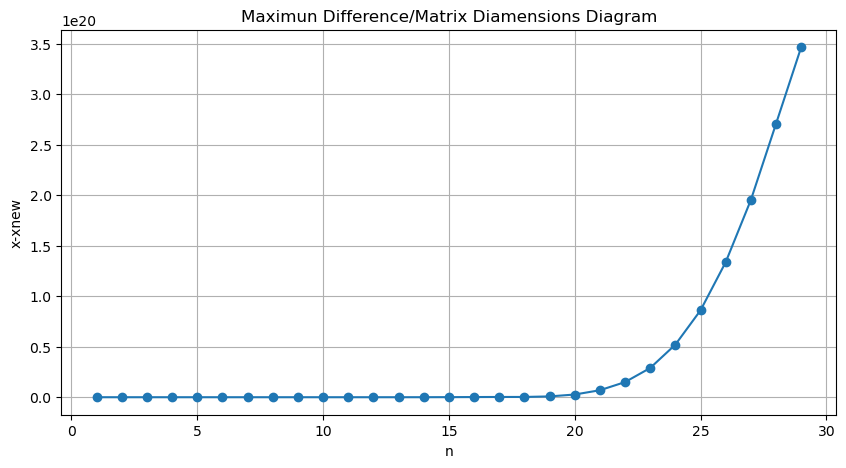

In [10]:
import matplotlib.pyplot as plt

def CreateHilbertMatrix2(n):    #Νέα συνάρηση για την δημηουργία πίνακα, ώστε να μπορεί να εκτελέιται για διαδοχικές τιμές του n
    matrix=np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            matrix[i][j] =1/(i+j+1)
    return matrix

def XXnew(n):    #Συνάρτηση με όρισμα n ώστε να λάβουμε την τιμή μέγιστης διαφορας για διαδοχικά n
    H=CreateHilbertMatrix2(n)
    b=CreateVector(H)
    L,U=LUmine(H)
    x=SolveWithQR(L,U,b)
    bnew=b.copy()
    bnew[0][0]+=0.00000000000001
    xnew=SolveWithLU(L,U,bnew)
    return np.max(np.abs(x-xnew))


N=list(range(1,30))  #Οι τιμές του n που θα απεικονίσουμε


npmax=[XXnew(n) for n in N]    #Η μέγιστη διαφορά για κάθε n 


plt.figure(figsize=(10,5))    #Μέγεθος διαγράμματος σε ίντσες
plt.plot(N,npmax,marker='o')     #Επισήμανση των σημέιων τομής n/x-xnew με κυκλάκια
plt.title('Maximun Difference/Matrix Diamensions Diagram')    #Τίτλος διαγράμματος
plt.xlabel('n')    #Τίτλος του x άξονα
plt.ylabel('x-xnew')    #Τίτλος του y άξονα
plt.grid(True)    #Ορατό Grid 
plt.show()


(ε) ΑΝΤΙΣΤΡΟΦΗ ΠΙΝΑΚΩΝ HILBERT, ΔΗΜΙΟΥΡΓΙΑ ΔΙΑΓΡΑΜΜΑΤΟΣ 2-ΝΟΡΜΑΣ/n:
Η 2-νόρμα της πράξης I-HH^-1 θα έπρεπε να είναι μηδενική. Είναι αναμενόμενο να προκύψουν ορισμένα υπολογιστικά σφάλματα, οπότε κάποιες μικρές τιμές θα ήταν αποδεκτές. Αυτο που παρατηρούμε ωστόσο, είναι πως για διψήφια n, η νόρμα της διαφορες παίρνει τιμές που κυμαίνονται από δεκάδες έως και εκατοντάδες. Αυτό επιβεβαιώνει για ακόμα μια φορά την αστάθεια των πινάκων Hilbert. Πίνακες με μεγάλο condition number, δημιουργούν ανακρίβειες στις αριθμητικές μεθόδους. Η διαδικασία της αντιστροφής δεν αποτελεί εξαίρεση. Επιπλέον, όσο μεγαλώνει η διάσταση του Hilbert, τόσο μεγαλώνει το condition number. Έτσι, η αστάθεια και η ευαισθησία σε ανακρίβιες εντίνονται.

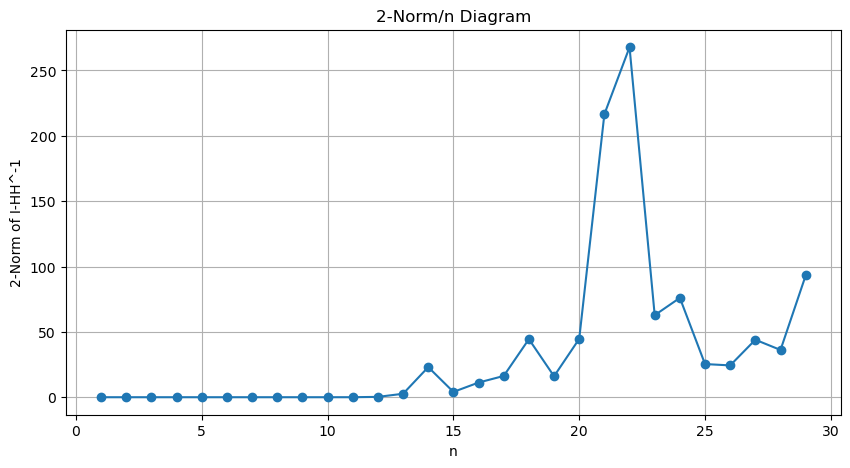

In [11]:
def LNormHI(n):    #Συνάρτηση πυ επιστρέφει την διαφορά για τις διάφορες τιμές του n
    H=CreateHilbertMatrix2(n)
    Hinv=np.linalg.inv(H)
    I=np.identity(n)
    dif=np.linalg.norm(H@Hinv-I)
    return dif

N=list(range(1,30))  #Οι τιμές του n που θα απεικονίσουμε


norm=[LNormHI(n) for n in N]    #Η 2-νόρμα για κάθε n 

plt.figure(figsize=(10,5))    
plt.plot(N,norm ,marker='o')     
plt.title('2-Norm/n Diagram')    
plt.xlabel('n')    
plt.ylabel('2-Norm of I-HH^-1')    
plt.grid(True)    
plt.show()


ΠΡΟΒΛΗΜΑ ΠΡΟΣΕΓΓΙΣΗΣ ΜΕ ΜΕΘΟΔΟ QR:
Στην επίλυση προβλημάτων ελαχίστων τετραγώνων που αφορούν την δημιουργία πολυωνύμου προσέγγισης συνήθως χρειάζεται η δημιουργία πίνακα, ο οποίος θα έχει ως στήλες τις δυνάμεις του διανύσματος t (βλ. βιβλίο Πιτσούλη σελ. 105).Βρήκαμε πως ο πίνακας αυτός ονομάζεται Vandermonde και στην Python υπάρχει συγκεκριμένη εντολή για την δημιουργία του.Κάθε γραμμή του αντιπροσοπεύει ένα σημείο προσσέγγισης και κάθε στήλη την αντίστοιχη δύναμη του t, από 4 έως Ο. πίνακας αυτός θα είναι επομένως διάστασης 50Χ5. Έτσι, κάναμε ορισμένες αλλαγές στην συνάρτηση QRmine ώστε να μπορούν να επεξεργαστούν και μη τετραγωνικούς πίνακες. Προχωράμε μετά στην αρχικοποίηση των διανυσμάτων. Το διάνυσμα t αντιπροσωπεύει τα σημεία σύγκλισης.Αρχικοποιείται με την συνάρτηση np.linespace(a,b,c), η οποία δημιουργεί μονοδιάστατο πίνακα που περιέχει c ισαπέχοντα σημειά μεταξύ των a και b. Όσον αφορά το διάνυσμα y, πρόκειται για συνάρτηση που έχει ως ανεξάρτητη μεταβλητή το t και εισάγει τυχαίο θόρυβο προσθέτωντας το np.random.randn(t.shape[0]). Η εντολή αυτή δημιουργεί πίνακα μεγέθους t και τον γεμίζει με στοιχεία n->N~(0,1). Στην συνέχεια, πραγματοποιούμε την παραγωντοποίηση QR. Η επαλήθευση θα έπρεπε να δίνει 0, ωστόσο το σφάλμα που βλέπουμε είναι αμελητέο. Αμέσως μετά λύνουμε το σύστημα Vx=y <=> QRx=y. Από την επίλυση του συστήματος αυτού, παίρνουμε το xQR, το οποίο είναι διάνυσμα 1Χ5 που περιέχει τους συντελεστές του πολυωνύμου προσέγγισης.Το error δίνεται απο την πράξη (V@x-y)^2. Παρατηρούμε ότι η τιμή του error και του xQR αλλάζει σε κάθε κλίση της συνάρτησης. Αυτό προκαλείται από τον  τυχαίο θόρυβο που εισάγουμε στο σύστημα μέσω του y. Η συνάρτηση FormPolynomial, δέχεται ως ορίσματα δύο διάνυσματα. Ένα παραμέτρων και ένα συντελεστών. Έτσι, σχηματίζει και επιστρέφει το αντίστοιχο πολυώνυμο. Σχετικά με το διάγραμμα, έχουμε δύο απεικονίσεις. Μια είναι αυτή των σημείων. Τα 50 σημεία t αντιστοιχίζονται σε ένα σημείο της y και σημαδεύονται με μπλε βουλίτσες. Η δεύτερη απεικόνιση αφορά το πολυώνυμο P(t), η καμπύλη του οποίου είναι δείγμα για το πόσο αποτελεσματική είμασταν στην προσσέγγισή μας. Εδώ να σημειώσουμε πως η "τετραγωνοποίση" του συστήματος εκτελείται έμμεσα. Η διαδικασία Αx=b όπου A=QR => (A^T)Ax=A^Tb => (QR)^TQRx=(QR)^Tb => (R^T)(Q^TQ)Rx=R^TQ^Tb => Rx=Q^Tb, πλεόν γίνεται Αx=b => QRx=b => Q^TQRx=Q^Tb => Rx=Q^Tb.

7.72655811160991e-16




[ -3.14693362  13.18889231 -11.91250949   0.20506427   0.99459244]



0.5126286228826257


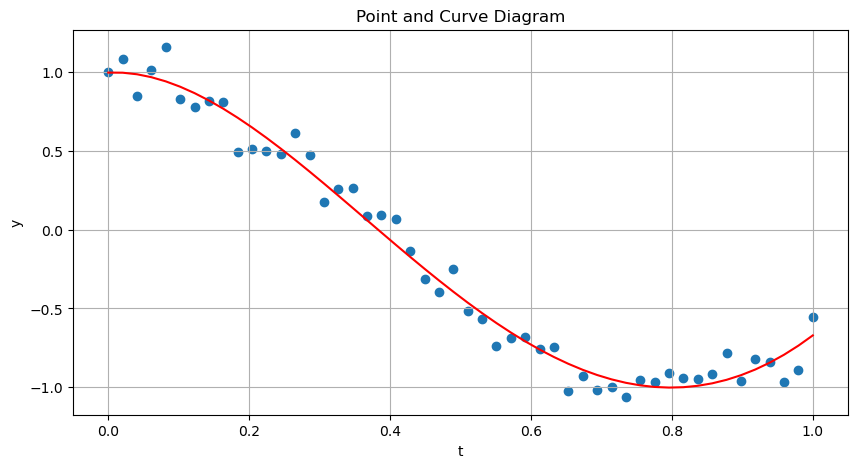

In [12]:
def QRmine2(A):
    m,n=A.shape    
    Q=np.zeros((m,n))    #Ο πίνακας Q πάιρνει πλεόν τις διαστάσεις του εκάστοτε μη τετραγωνικού πίνακα
    R=np.zeros((n,n))
    for j in range(n):    
        q=np.array(A[:,j])    
        v=q.copy()    
        for i in range(j):    
            R[i,j]=np.dot(Q[:,i],v)    
            q=q-R[i,j]*Q[:,i]   
        R[j,j]=np.linalg.norm(q)    
        Q[:,j]=q/R[j,j]    
    return Q,R

t=np.linspace(0,1,50)    #Αρχικοποίηση των διανυσμάτων

y=np.cos(4*t)+0.1*np.random.randn(t.shape[0])

V=np.vander(t,5)    #Αρχικοποίηση του πίνακα Vandermonde


Q,R=QRmine2(V)

print(np.linalg.norm(V-Q@R))    #Επαληθεύουμε

print("\n\n\n")

xQR=SolveWithQR(Q,R,y)    #Λύνουμε το σύστημα

print(str(xQR)+"\n\n\n")

ErQR=(V@xQR-y)**2    

print(np.sum(ErQR))

#Δημιουργία διαγράμματος:

def FormPolynomial(x,xc):
    p=xc[0]*x**4+xc[1]*x**3+xc[2]*x**2+xc[3]*x+xc[4]
    return p

plt.figure(figsize=(10,5))    
plt.scatter(t,y,marker='o')
plt.plot(t,FormPolynomial(t,xQR),color='red')
plt.title('Point and Curve Diagram')   
plt.xlabel('t')
plt.ylabel('y') 
plt.grid(True)    
plt.show()

ΠΡΟΣΕΓΓΙΣΗ ΜΕ ΜΕΘΟΔΟ LU:

Στο παρόν πρόγραμμα, επιλέξαμε μια πιο manual υλοποίηση του πίνακα V, που ως στήλες περιέχει τις δυνάμεις του t. Το ζητούμενο είναι η επίλυση του συστήματος V2x=y, ώστε να προκύψουν τα οι x[i] συντελεστές του P(t). Με την μέθοδο LU αυτό δεν θα ήταν δυνατό επειδή αφορά μόνο τετραγωνικούς πίνακες. Έτσι, σύμφωνα με την μέθοδο του θεωρήματος 5.6 του βιβλίου, τροποποιόυμε την εξίσωση. Πολλαπλασιάζουμε και τα δύο μέλη με V transpose, ώστε στο πρώτο να προκύψει πίνακας Α διαστάσεων 5Χ5 και στο δεύτερο διάνυσμα b 1X5. Στην συνέχεια, πραγματοποιούμε την παραγοντοποίηση LU και λύνουμε στο σύστημα.

3.66205343881779e-15




[ -2.9410385   13.13442933 -12.29401085   0.34295808   1.01882687]



0.4112167009588494


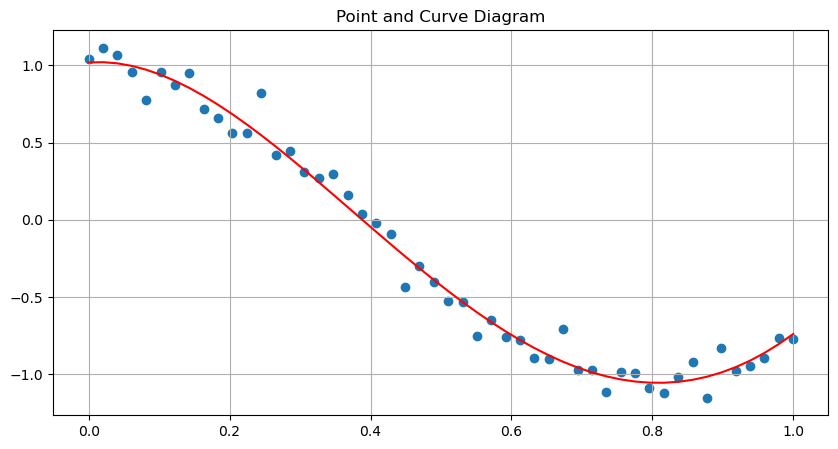

In [13]:
t=np.linspace(0,1,50)    #Αρχικοποίηση των διανυσμάτων

y=np.cos(4*t)+0.1*np.random.randn(t.shape[0])

n=5    #Εναλλακτική αρχικοποίηση του πίνακα Vandermonde
m=len(t)
V2=np.zeros((m,n))

for i in range(n):
    V2[:,i]=t**(n-i-1)

A=V2.T@V2
b=V2.T@y
L,U=LUmine(A)


print(np.linalg.norm(A-L@U))    #Επαληθεύουμε

print("\n\n\n")

xLU=SolveWithLU(L,U,b)

print(str(xLU) +"\n\n\n")

ErLU=(V2@xLU-y)**2    

print(np.sum(ErLU))







plt.figure(figsize=(10, 5))    
plt.scatter(t, y, marker='o')
plt.plot(t, FormPolynomial(t, xLU), color='red')
plt.title('Point and Curve Diagram')     
plt.grid(True)    
plt.show()

ΣΥΓΚΡΙΣΗ ΤΩΝ ΔΥΟ ΜΕΘΟΔΩΝ: Ακολουθούν οι δυο μέθοδοι συγκεντρωμένες, με μία κλήση του y, ώστε να συγκριθεί η ακρίβειά τους. Όπως διαπιστώνουμε, οι μέθοδοι αισίως είναι ίδιας ακρίβειας για 15 δεκαδικά ψηφία . Η παρατήρηση αυτή θα μπορούσε ίσως να συνδεθεί με τα σχόλια που κάναμε στο ερώτημα (β), επιβεβαιώνοντας κάπως πως εν τέλει οι διαφορές που βλέπαμε στην επίλυση του συστήματος αφορούσαν την φύση των πινάκων Hilbert και όχι τόσο τις μεθόδους μας.

0.5550373793936833
0.5550373793936815


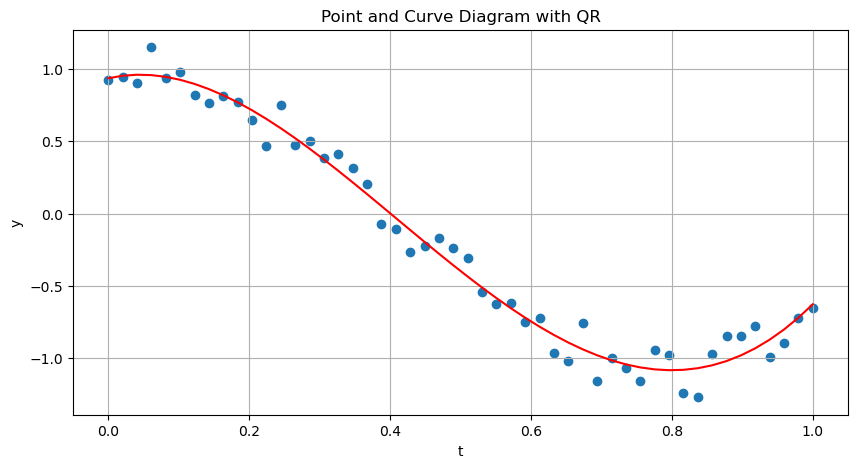

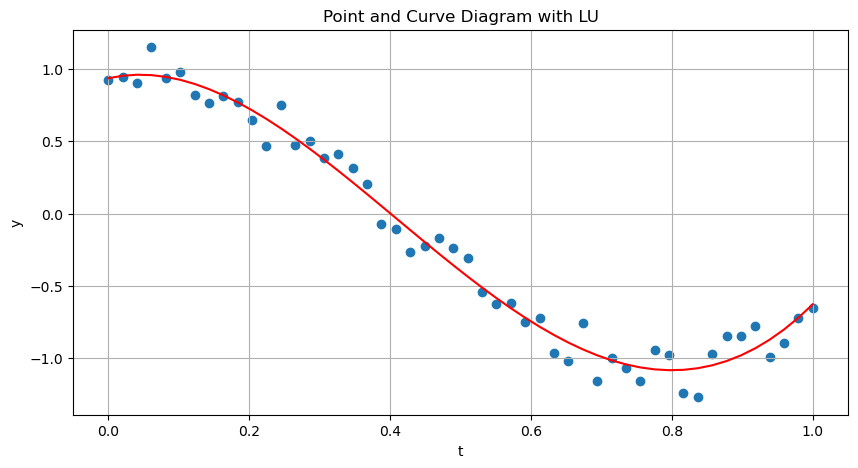

In [14]:
t=np.linspace(0,1,50)    

y=np.cos(4*t)+0.1*np.random.randn(t.shape[0])

V=np.vander(t,5)    


Q,R=QRmine2(V)

xQR=SolveWithQR(Q,R,y)

A=V.T@V
b=V.T@y
L,U=LUmine(A)

xLU=SolveWithLU(L,U,b)


ErQR=(V@xQR-y)**2    

print(np.sum(ErQR))

ErLU=(V2@xLU-y)**2    

print(np.sum(ErLU))



plt.figure(figsize=(10, 5))    
plt.scatter(t, y, marker='o')
plt.plot(t, FormPolynomial(t, xQR), color='red')
plt.title('Point and Curve Diagram with QR')   
plt.xlabel('t')
plt.ylabel('y') 
plt.grid(True)    
plt.show()



plt.figure(figsize=(10, 5))    
plt.scatter(t, y, marker='o')
plt.plot(t, FormPolynomial(t, xLU), color='red')
plt.title('Point and Curve Diagram with LU')  
plt.xlabel('t')
plt.ylabel('y') 
plt.grid(True)    
plt.show()
